Map_of_countries_by_GDP_(PPP)_per_capita_in_2024.svg

# **GDP Forecasting and Ranking Analysis per Country**
**Notebook Description**

This notebook provides an end-to-end analysis and prediction of GDP per country. It covers the following main steps:

---

1.  Data Preprocessing

*   Loaded GDP dataset containing multiple years and percentage changes.
*   Cleaned column names and converted year values into numeric format.
*   Handled missing values using forward-fill and back-fill techniques to ensure continuous time series per country.


2.   Data Transformation

*   Reshaped dataset into a tidy long format (Country – Year – GDP).
*   Converted year columns into integer values.
*   Computed country-wise GDP ranks per year to track global positioning.


3.   Modeling & Prediction

*   Applied RandomForestRegressor to learn GDP trends across years.
*   Predicted GDP for 2026 for each country.
*   Integrated predictions back into the dataset for comparison.


4.   Visualization

*   Displayed top 10 countries GDP (2025 vs predicted 2026).
*   Created line plots for selected countries showing historical GDP (2020–2025) and predicted 2026 GDP.
*   Highlighted year-wise GDP ranking dynamics across countries.


5.   Insights

*   Identified leading economies and how their ranking changes over years.
*   Generated a forward-looking 2026 projection to support economic analysis and decision-making.

In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler, RobustScaler, Normalizer

In [234]:
df = pd.read_csv("/content/2020-2025.csv")
df

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0
...,...,...,...,...,...,...,...
191,Vietnam,346310,370076.0,411068.0,433008.0,459472.0,490970.0
192,Palestine,15532,18109.0,19166.0,17848.0,NaN,NaN
193,Yemen,20220,19394.0,23534.0,19412.0,19101.0,17401.0
194,Zambia,18138,22096.0,29164.0,27578.0,26326.0,28910.0


In [235]:
df.shape

(196, 7)

In [236]:
df.columns

Index(['Country', '2020', '2021', '2022', '2023', '2024', '2025'], dtype='object')

In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In [238]:
df.describe()

,2020,2021,2022,2023,2024,2025
count,1.960000e+02,1.940000e+02,1.940000e+02,1.940000e+02,1.920000e+02,1.890000e+02
mean,4.378886e+05,5.043504e+05,5.255064e+05,5.486173e+05,5.756871e+05,5.991414e+05
std,1.942936e+06,2.220864e+06,2.347886e+06,2.453040e+06,2.573189e+06,2.693421e+06
min,5.200000e+01,6.200000e+01,6.100000e+01,6.300000e+01,6.500000e+01,6.500000e+01
25%,9.588000e+03,1.114175e+04,1.265000e+04,1.360450e+04,1.350050e+04,1.421400e+04
50%,3.533450e+04,3.771900e+04,4.156800e+04,4.363100e+04,4.713550e+04,4.782900e+04
75%,2.074810e+05,2.546132e+05,2.746308e+05,2.850355e+05,2.915108e+05,3.032930e+05
max,2.135412e+07,2.368118e+07,2.600690e+07,2.772072e+07,2.918490e+07,3.050722e+07


In [239]:
df.duplicated().sum()

np.int64(0)

In [240]:
df.isnull().sum()

,0
Country,0
2020,0
2021,2
2022,2
2023,2
2024,4
2025,7


In [241]:
for year in ['2020','2021','2022','2023','2024','2025']:
    median_val = df[year].median()
    df[year].fillna(median_val, inplace=True)

/tmp/ipython-input-2373082327.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[year].fillna(median_val, inplace=True)


In [242]:
df.isnull().sum()

,0
Country,0
2020,0
2021,0
2022,0
2023,0
2024,0
2025,0


# **Data visualization**

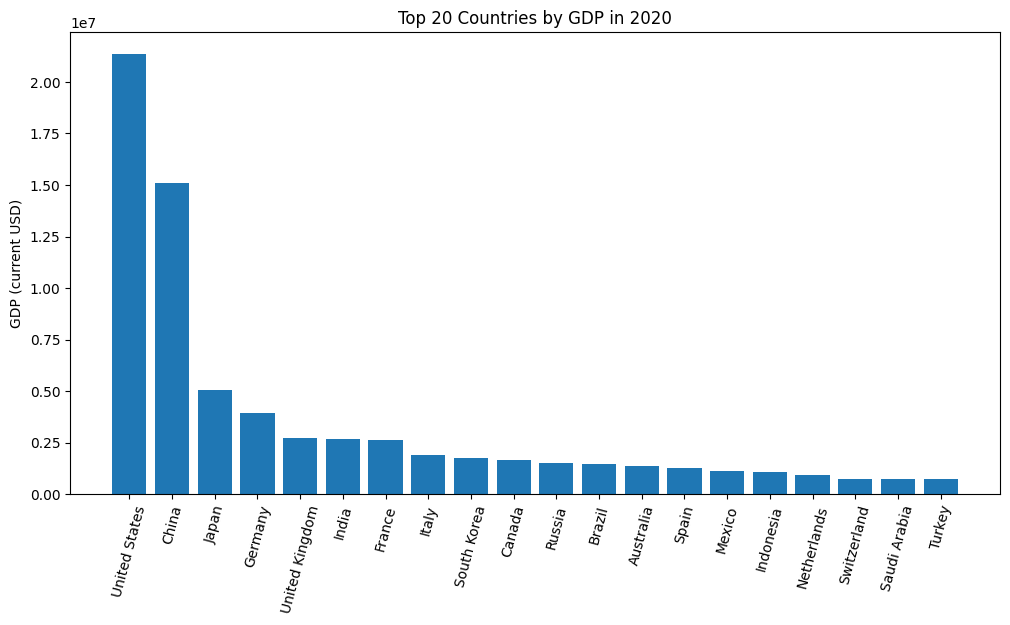

In [243]:
top20_2020 = df[['Country', '2020']].sort_values(by='2020', ascending=False).head(20)
plt.figure(figsize=(12,6))
plt.bar(top20_2020['Country'], top20_2020['2020'])
plt.xticks(rotation=75)
plt.title("Top 20 Countries by GDP in 2020")
plt.ylabel("GDP (current USD)")
plt.show()

/tmp/ipython-input-2905301352.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="2025", y="Country", data=top10, palette="viridis")


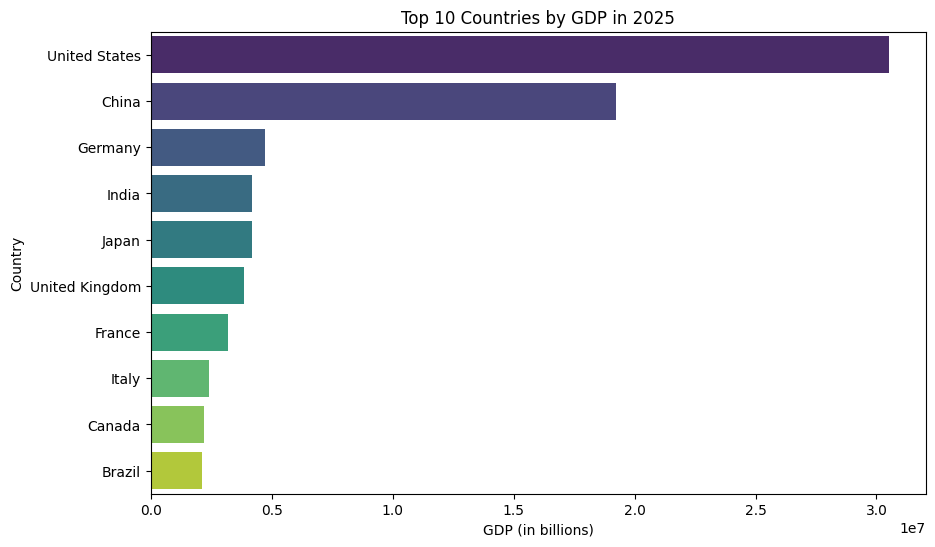

In [244]:
top10 = df.nlargest(10, "2025")
plt.figure(figsize=(10,6))
sns.barplot(x="2025", y="Country", data=top10, palette="viridis")
plt.title("Top 10 Countries by GDP in 2025")
plt.xlabel("GDP (in billions)")
plt.ylabel("Country")
plt.show()

In [253]:
df.columns = [str(c) for c in df.columns]

year_cols = [c for c in df.columns if c.isdigit()]

for c in year_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[year_cols] = df[year_cols].ffill(axis=1)
df[year_cols] = df[year_cols].bfill(axis=1)

tidy = df.melt(id_vars="Country", value_vars=year_cols,
               var_name="Year", value_name="GDP")

tidy["Year"] = tidy["Year"].astype(int)

tidy = tidy.sort_values(["Year", "GDP"], ascending=[True, False]).reset_index(drop=True)

tidy["Rank"] = tidy.groupby("Year")["GDP"].rank(method="first", ascending=False)

print(tidy.head(10))


          Country  Year         GDP  Rank
0   United States  2020  21354125.0   1.0
1           China  2020  15103357.0   2.0
2           Japan  2020   5054069.0   3.0
3         Germany  2020   3936989.0   4.0
4  United Kingdom  2020   2698705.0   5.0
5           India  2020   2674852.0   6.0
6          France  2020   2645806.0   7.0
7           Italy  2020   1905956.0   8.0
8     South Korea  2020   1744456.0   9.0
9          Canada  2020   1655685.0  10.0


In [254]:
def pick_countries(n=10, by_year=2025, min_gdp=None, include=None):
    """
    Pick a set of countries to plot lines for.
    - n: top-N by GDP in `by_year`
    - min_gdp: minimum GDP threshold in `by_year` (overrides n if used)
    - include: list of country names to always include
    """
    year_df = tidy[tidy["Year"] == by_year].dropna(subset=["GDP"])
    chosen = set()
    if min_gdp is not None:
        chosen.update(year_df[year_df["GDP"] >= min_gdp]["Country"].head(196).tolist())
    else:
        chosen.update(year_df.sort_values("GDP", ascending=False)["Country"].head(n).tolist())
    if include:
        chosen.update(include)
    return sorted(chosen)
def plot_lines(countries=None, start=2020, end=2025):
    data = tidy[(tidy["Year"]>=start) & (tidy["Year"]<=end)]
    if countries is None:
        countries = pick_countries(n=10, by_year=end)
    fig, ax = plt.subplots(figsize=(10,6))
    for c in countries:
        sub = data[data["Country"]==c].sort_values("Year")
        ax.plot(sub["Year"], sub["GDP"], label=c, linewidth=2)
    ax.set_title(f"GDP Evolution {start}-{end}")
    ax.set_xlabel("Year")
    ax.set_ylabel("GDP")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

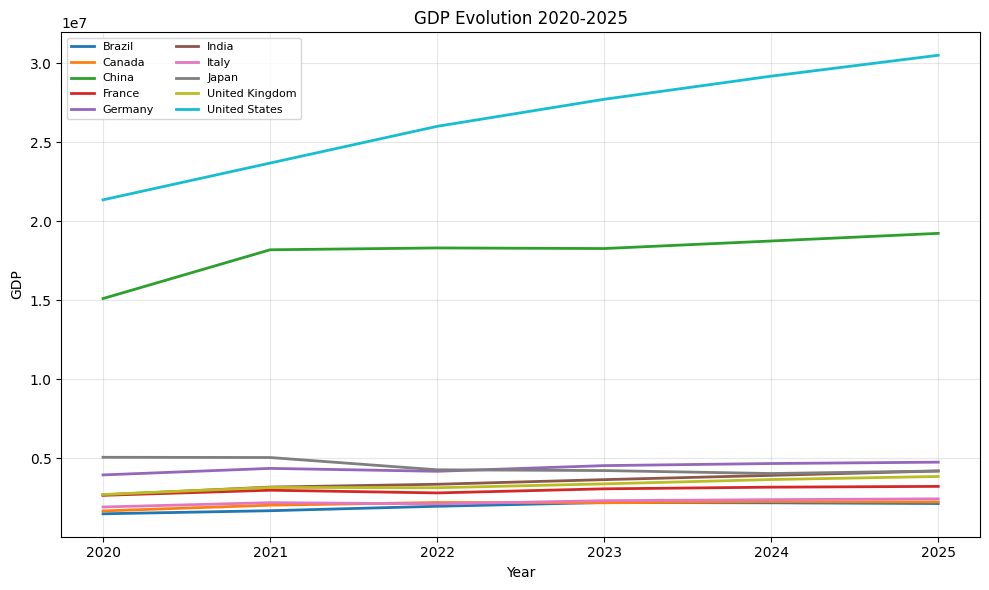

In [255]:
plot_lines()

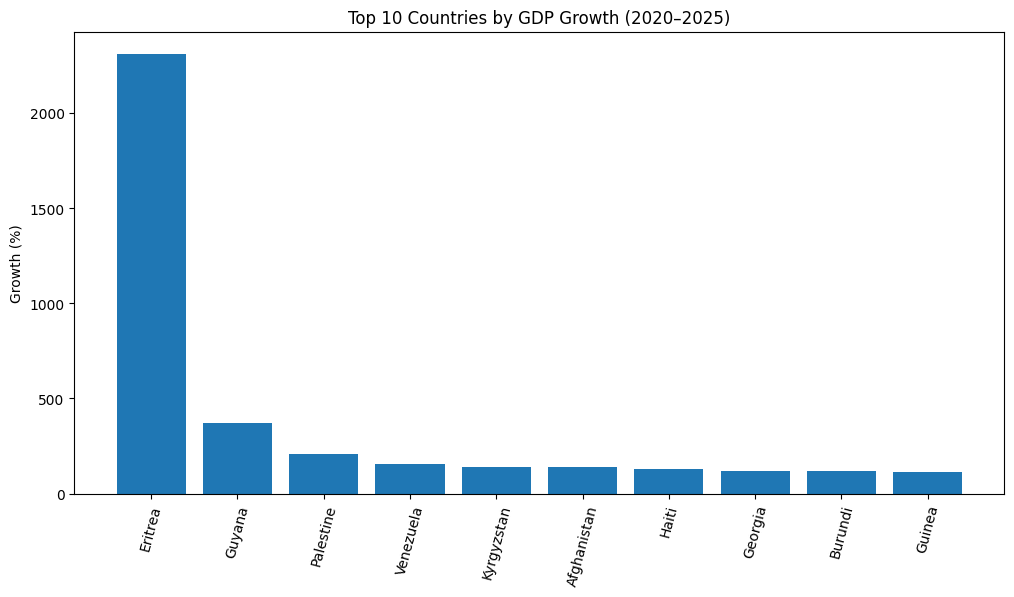

In [245]:
df['Change_2020_2025_%'] = ((df['2025'] - df['2020']) / df['2020']) * 100
df[['Country', '2020', '2025', 'Change_2020_2025_%']].sort_values(by='Change_2020_2025_%', ascending=False).head(10)

top10_growth = df.sort_values(by='Change_2020_2025_%', ascending=False).head(10)
plt.figure(figsize=(12,6))
plt.bar(top10_growth['Country'], top10_growth['Change_2020_2025_%'])
plt.xticks(rotation=75)
plt.title("Top 10 Countries by GDP Growth (2020–2025)")
plt.ylabel("Growth (%)")
plt.show()

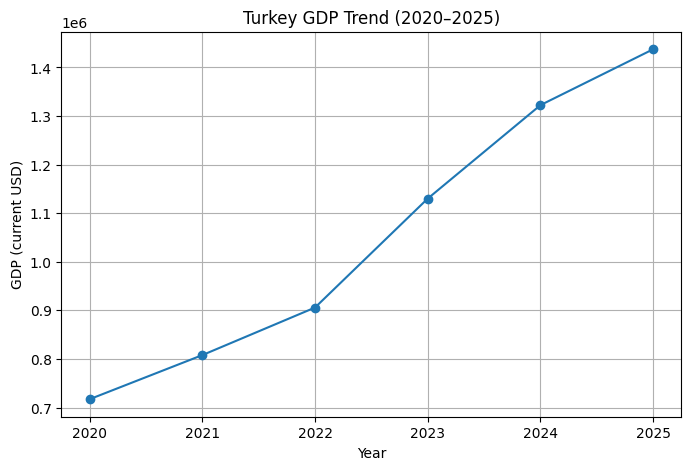

In [246]:
turkey = df[df['Country'] == 'Turkey'].iloc[0]
years = [2020, 2021, 2022, 2023, 2024, 2025]
values = [turkey[str(y)] for y in years]
plt.figure(figsize=(8,5))
plt.plot(years, values, marker='o')
plt.title("Turkey GDP Trend (2020–2025)")
plt.xlabel("Year")
plt.ylabel("GDP (current USD)")
plt.grid(True)
plt.show()

In [247]:
from sklearn.linear_model import LinearRegression

year_cols = ['2020', '2021', '2022', '2023', '2024', '2025']

for col in year_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # تحويل إلى أرقام
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

years = np.array([2020, 2021, 2022, 2023, 2024, 2025]).reshape(-1, 1)

df['2026_pred'] = np.nan

for i, row in df.iterrows():
    values = row[year_cols].values.astype(float)

    model = LinearRegression()
    model.fit(years, values)

    pred_2026 = model.predict(np.array([[2026]]))[0]
    df.at[i, '2026_pred'] = pred_2026

print(df[['Country', '2025', '2026_pred']].head(10))

               Country       2025     2026_pred
0          Afghanistan    47829.0  5.083303e+04
1              Albania    28372.0  3.164953e+04
2              Algeria   268885.0  3.043024e+05
3              Andorra     4035.0  4.404067e+03
4               Angola   113343.0  1.350130e+05
5  Antigua and Barbuda     2373.0  2.595467e+03
6            Argentina   683533.0  7.717691e+05
7              Armenia    26258.0  3.108007e+04
8                Aruba     4100.0  4.550067e+03
9            Australia  1771681.0  1.924333e+06


/tmp/ipython-input-3960100821.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


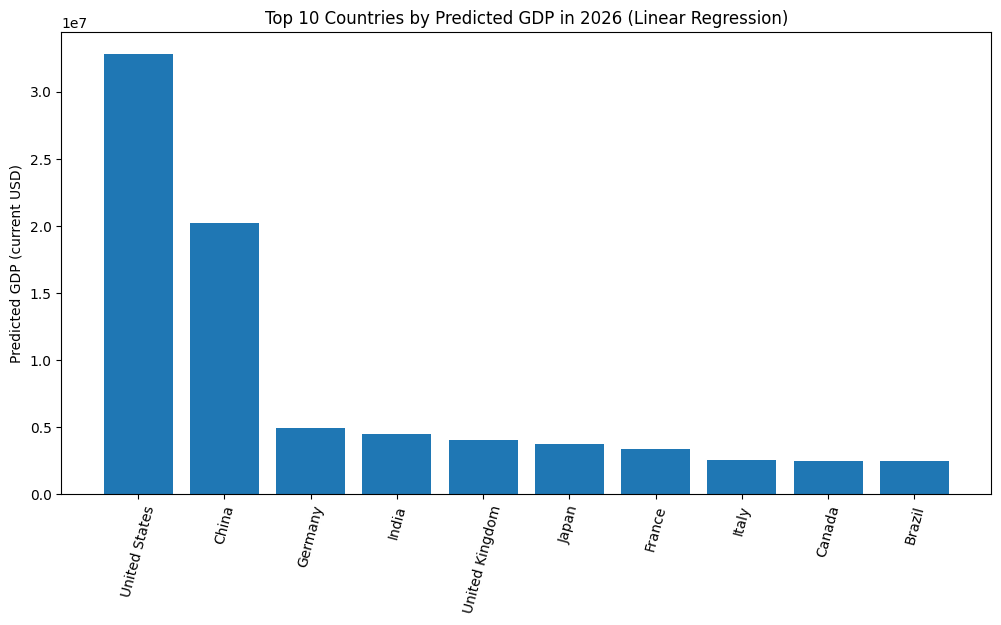

In [248]:
top10_2026 = df[['Country', '2026_pred']].sort_values(by='2026_pred', ascending=False).head(10)
top10_2026
plt.figure(figsize=(12,6))
plt.bar(top10_2026['Country'], top10_2026['2026_pred'])
plt.xticks(rotation=75)
plt.title("Top 10 Countries by Predicted GDP in 2026 (Linear Regression)")
plt.ylabel("Predicted GDP (current USD)")
plt.show()

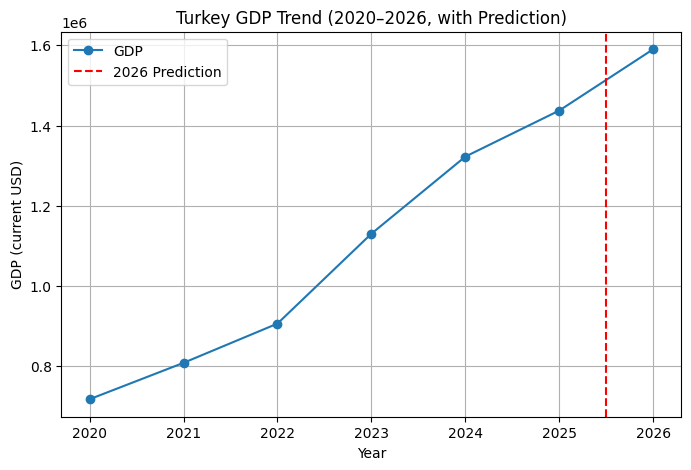

In [249]:
turkey = df[df['Country'] == 'Turkey'].iloc[0]

years = [2020, 2021, 2022, 2023, 2024, 2025]
values = [turkey[str(y)] for y in years]

gdp_2026 = turkey['2026_pred']

years_extended = years + [2026]
values_extended = values + [gdp_2026]


plt.figure(figsize=(8,5))
plt.plot(years_extended, values_extended, marker='o', label="GDP")
plt.axvline(2025.5, color='red', linestyle='--', label="2026 Prediction")
plt.title("Turkey GDP Trend (2020–2026, with Prediction)")
plt.xlabel("Year")
plt.ylabel("GDP (current USD)")
plt.grid(True)
plt.legend()
plt.show()

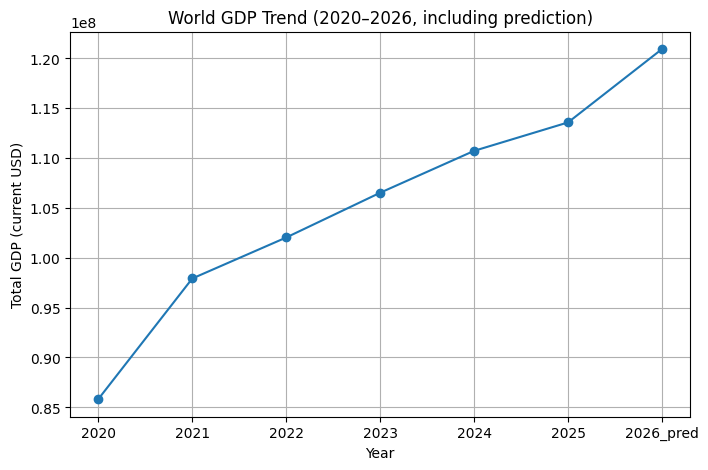

In [250]:
world_gdp = df[['2020','2021','2022','2023','2024','2025','2026_pred']].sum()

years = world_gdp.index.tolist()
values = world_gdp.values

plt.figure(figsize=(8,5))
plt.plot(years, values, marker='o')
plt.title("World GDP Trend (2020–2026, including prediction)")
plt.xlabel("Year")
plt.ylabel("Total GDP (current USD)")
plt.grid(True)
plt.show()

               Country       2025     2026_pred
0          Afghanistan    47829.0  5.083303e+04
1              Albania    28372.0  3.164953e+04
2              Algeria   268885.0  3.043024e+05
3              Andorra     4035.0  4.404067e+03
4               Angola   113343.0  1.350130e+05
5  Antigua and Barbuda     2373.0  2.595467e+03
6            Argentina   683533.0  7.717691e+05
7              Armenia    26258.0  3.108007e+04
8                Aruba     4100.0  4.550067e+03
9            Australia  1771681.0  1.924333e+06


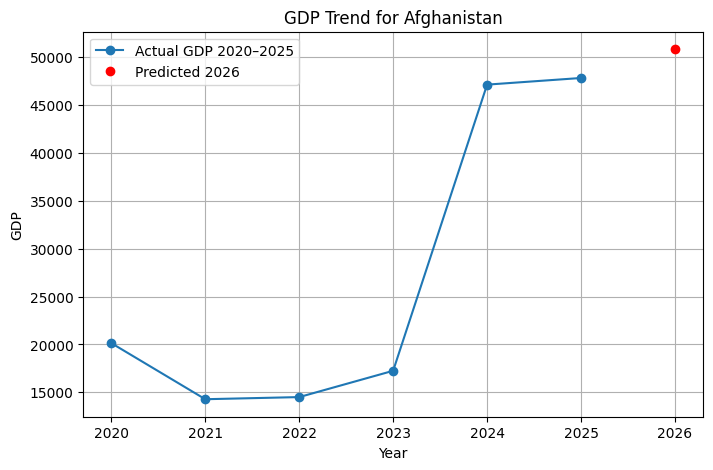

In [251]:
years = np.array([2020, 2021, 2022, 2023, 2024, 2025])

print(df[['Country', '2025', '2026_pred']].head(10))

country_example = df.iloc[0]
values = country_example[year_cols].values.astype(float)

plt.figure(figsize=(8,5))
plt.plot(years, values, marker='o', label='Actual GDP 2020–2025')
plt.plot(2026, country_example['2026_pred'], 'ro', label='Predicted 2026')
plt.title(f"GDP Trend for {country_example['Country']}")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.legend()
plt.grid(True)
plt.show()
